<a href="{{ colab_base_laboratorios }}/Laboratorio_10_nn_keras__V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Lab 10: Red neuronal con keras



| Función de activación | Ventajas | Desventajas |
| --------------------- | -------- | ----------- |
| Lineal | Simple y rápida de calcular | Le falta introducir no linealidad, no limita el rango de salida |
| Sigmoide | Mapea la salida al rango (0, 1), útil para clasificación binaria | Se satura fácilmente, tiene gradientes pequeños, no tiene media cero |
| Tangente hiperbólica | Mapea la salida al rango (-1, 1), tiene media cero, es más fuerte que la sigmoide | Se satura fácilmente, tiene gradientes pequeños |
| ReLU | Introduce no linealidad, tiene gradientes grandes, es rápida de calcular | Puede morir si la entrada es negativa, no tiene media cero |


# Keras: https://keras.io/api/layers/activations/

Keras es una bilbioteca con librerias de código abierto para entrenar modelos de deep learning DL que puede ejecutarse en TensorFlow. Keras permite construir bloque de arquitectura de la redes neuronales, y permite construir desde un perceptron hasta redes neuronales convolucionales  y recurrentes de una manera amigable con el usuario.


# Funciones de activación

Tipos de funciones de activación:

## Lineal:

Una transformación lineal, la cual se muestra en la siguiente figura, consiste básicamente, en la función identidad. En estra transformación, la variable dependiente tiene una relación directa y proporcional con la variable independiente. En términos prácticos, lo anterior significa que una función de activación lineal pasa la señal sin realizar un cambio sobre esta. Este el típo de activación que se usa en la capa de entrada de las redes neuronales.


## Sigmoide:
Como todas las transformaciones logísticas, las sigmoides puede reducir la cantidad de valores extremos o outliers en los datos sin eliminarlos. En la siguiente figura se ilustra dicha función sigmoide:

Una función sigmoide convierde una variable independiente de rango infinito en probabilidades con un rango entre 0 y 1. La mayoria de las salidas serán cercanas a 0 o 1, que corresponden a zonas de saturación.

La función de activación sigmoide devuelve una probabilidad independiente para cada clase.



##  Tanh
Corresponde a una función trigonométrica hiperbólica donde el rango de salida de tanh varía entre -1 y 1, note la diferencia con la función sigmoide. La ventaja de tanh es puede tratar los números negativos de forma más eficiente que la función sigmoide.


## ReLU: Rectified Linear Unit (Unidad Rectificadad Lineal)
La unidad rectificada lineal es una trasformación más intersante que activa un nodo solo si la entrada se encuentra por encima de cierta cantidad. Si la entrada está por debajo de zero, la salida es cero, pero si la entrada alcanza un valor umbral, la salida tiene una relación lineal con la variable dependiente.

Las funciones de activaciones ReLU representan actualmente el estado de arte en la aplicación de funciones de activación, ya que han demostrado un buen desempeño en diferentes situaciones. Dado que el gradiente de la ReLU es cero o constante, permite evitar el problema del desvanecimiento del gradiente. Las funciones de activación ReLu han demostrado un mejor entrenamiento en la práctica que las funciones de activación sigmoidea.

Las funciones de activación ReLU se usan, normalmente, en las capas ocultas.

Existen mas funciones de activación, no obstante, nos centraremos a continuación solo en una más. Esta función de activación es usada en la capa de salida de la clasificación multiclase mediante una red neuronal. Es conocida como Softmax.


## Softmax
La función de activación Softmax representa una generalización de la regresión logística en el sentido que puede ser apllicada a un conjunto continuos de datos (en lugar de una clasificación binaria) y puede contener múltiples fronteras de desición. Esta función maneja sistemas multinomiales para el etiquetado. Softmax es una función que normalmente se usa en la capa de salida de un clasificador.

La función de activación Softmax devuelve la distribución de probablilidades de clases mutuamente excluyentes.

Consideremos el siguiente ejemplo en donde se ilustra, entre otra cosas la definición de la función SoftMax:

$S(y_i)=\frac{e^y_i}{\sum e^{y_i}}$


En deep learning, el térno capa logit se usa para la última capa de neuronas de la red neuronal para el problema de clasificación que produce unos valores de predicción "crudos" de valores reales que varian en el intervalo . En concreto, las cantidades logits son los puntajes crudos de la ultima capa de la red neuronal, antes de que se les aplique la activación.


Ref: https://github.com/ssanchezgoe/curso_deep_learning_economia/blob/main/NBs_Google_Colab/DL_S07_Funciones_Activacion_Arquitectura_Red.ipynb

In [ ]:
import numpy as np
from tensorflow import keras


In [ ]:
# 1: A través de una capa medidante el método Activación:
modelA = keras.models.Sequential()
modelA.add(keras.layers.Dense(32, input_shape=(16,)))
modelA.add(keras.layers.Activation('relu'))#  Capa activación
modelA.add(keras.layers.Dense(64))
modelA.add(keras.layers.Activation('tanh'))#  Capa activación
modelA.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,656 (10.38 KB)

 Trainable params: 2,656 (10.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 2: Mediante el argumento activation
modelB = keras.models.Sequential()
modelB.add(keras.layers.Dense(32, input_shape=(16,)))
modelA.add(keras.layers.Activation('relu'))#  Capa activación
modelB.add(keras.layers.Dense(64, activation='tanh'))
modelB.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         2,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,656 (10.38 KB)

 Trainable params: 2,656 (10.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 3: Mediante una función de Tensor-flow por elementos.
modelC = keras.models.Sequential()
modelC.add(keras.layers.Dense(32, activation='relu', input_shape=(16,)))
modelC.add(keras.layers.Dense(64, activation='tanh'))
modelC.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         2,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,656 (10.38 KB)

 Trainable params: 2,656 (10.38 KB)

 Non-trainable params: 0 (0.00 B)

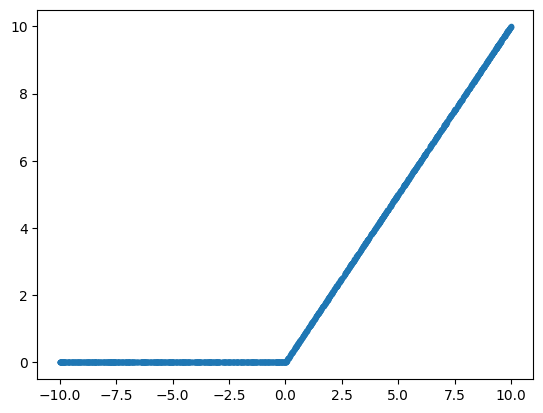

In [ ]:
# Vamos a graficar las funciones de activación y modificar los parámetros que las definen
# Encuentran los parámetros en https://keras.io/api/layers/activations/
# Relu
import matplotlib.pyplot as plt
x=np.random.uniform(low=-10.0, high=10, size=(2000,))
y=keras.activations.relu(x, negative_slope=0, max_value=None, threshold=0)
plt.plot(x,y,'.')

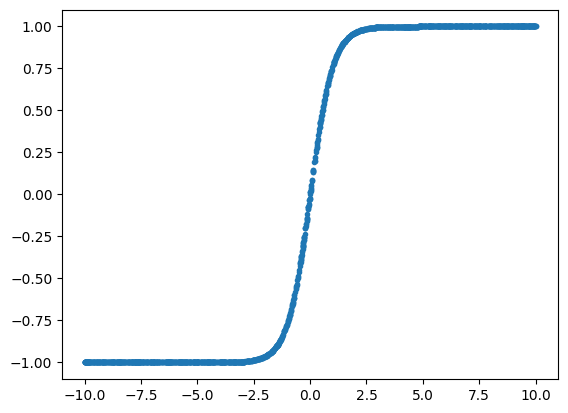

In [ ]:
# tanh
y=keras.activations.tanh(x)
plt.plot(x,y,'.')

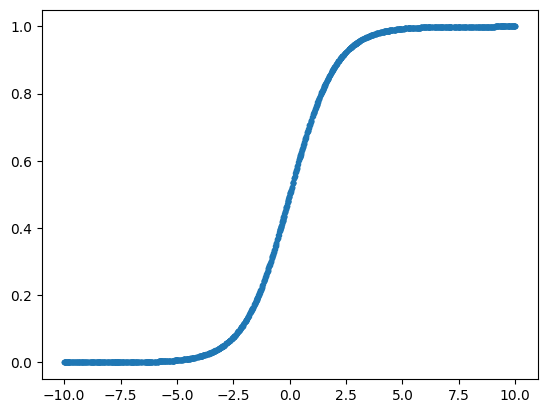

In [ ]:
#sigmoid
y=keras.activations.sigmoid(x)
plt.plot(x,y,'.')

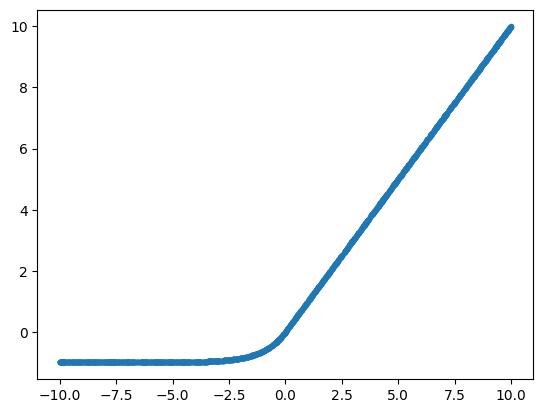

In [ ]:
# elu
y=keras.activations.elu(x, alpha=1.0)
plt.plot(x,y,'.')

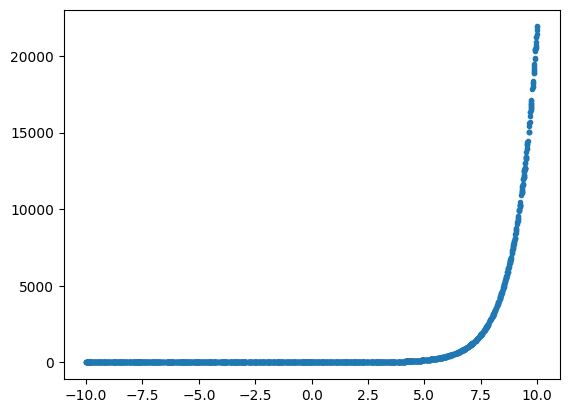

In [ ]:
# Exponential
y=keras.activations.exponential(x)
plt.plot(x,y,'.')

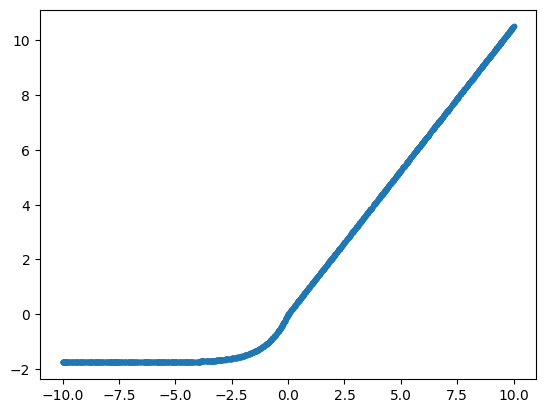

In [ ]:
# Selu
y=keras.activations.selu(x)
plt.plot(x,y,'.')

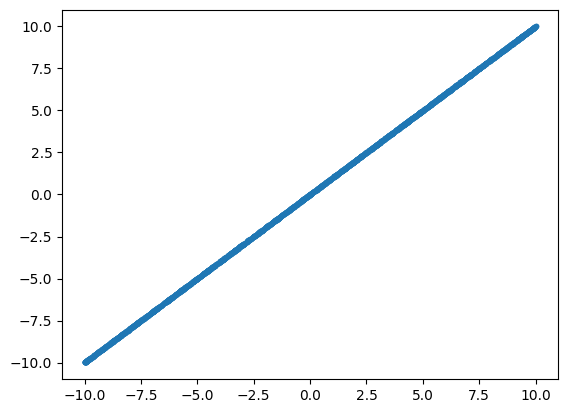

In [ ]:
# Linear
y=keras.activations.linear(x)
plt.plot(x,y,'.')

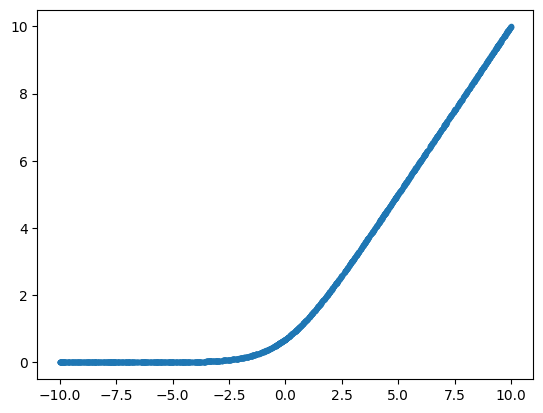

In [ ]:
y=keras.activations.softplus(x)
plt.plot(x,y,'.')


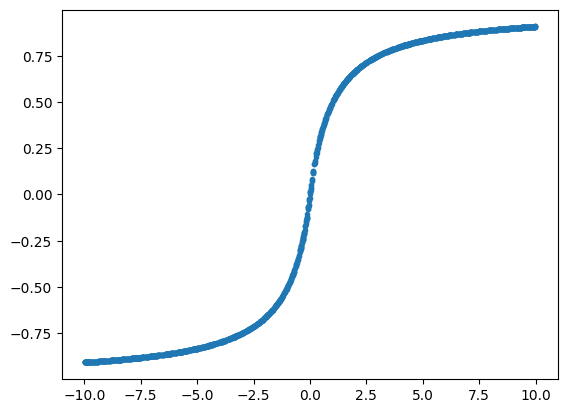

In [ ]:
y=keras.activations.softsign(x)
plt.plot(x,y,'.')

# Arquitectura y funcionalidad de la Redes neuronales secuenciales:

De las funciones de activación habladas en la clase anterior podemos advertir dos características que deben poseer una red neuronal:

Las funciones de activación de las capas ocultas deben ser funciones de activación no lineales, con el fín de que la red actue como un aproximador universal a una función.

La función de activación de la capa de salida determina el tipo de clasificación/regresión del problema que se pretende solucionar.
Como regla general, se tiene que la función de activación de las capas ocultas puede ser definida como una función ReLU y, dependiendo del problema, podemos definir la función de activación de la capa de salida como:

- Función de activación sigmoide: si el problema de clasificación es binario.
- Función de activación Softmax: si el problema de clasificación es multiclase.
- Función de activación lineal: si el problema se trata de una regresión.

En resumen, en la siguiente figura se ilustran la arquitectura de red de los problemas que pueden presentarse en la clasificación/regresión usando una red neuronal secuencial y las funciones de activación definidas en las capas que la componen.

In [ ]:
# https://github.com/ssanchezgoe/curso_deep_learning_economia/blob/main/NBs_Google_Colab/DL_S08_Problemas_FFNN.ipynb
# https://github.com/ssanchezgoe/curso_deep_learning_economia/blob/main/NBs_Google_Colab/DL_S11_DNN.ipynb

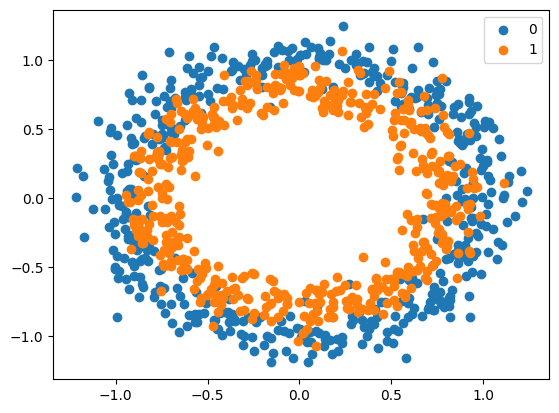

In [ ]:
# generación de círculos
# Algunas librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression, make_circles, make_blobs
from sklearn.preprocessing import StandardScaler
from tensorflow import keras

X, y = make_circles(n_samples=1000, noise=0.1, random_state=1)

plt.scatter(X[np.where((y==0)),0],X[np.where((y==0)),1], label='0')
plt.scatter(X[np.where((y==1)),0],X[np.where((y==1)),1], label='1')
plt.legend()
plt.show()

In [ ]:
# Creación del modelo
def build_model2(activation = 'sigmoid', loss='binary_crossentropy'):
  model = keras.models.Sequential()
  model.add(keras.layers.Dense(4, input_dim=2, activation='relu'))
  model.add(keras.layers.Dense(8, activation='relu'))
  model.add(keras.layers.Dense(1, activation = activation))
  opt = keras.optimizers.SGD(learning_rate=0.01)
  model.compile(loss=loss, optimizer=opt, metrics=['accuracy'])
  return model

#https://developers.google.com/machine-learning/crash-course/classification/accuracy#:~:text=Accuracy%20is%20one%20metric%20for,predictions%20Total%20number%20of%20predictions

Epoch 1/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.5200 - loss: 0.6893 - val_accuracy: 0.4980 - val_loss: 0.6900
Epoch 2/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5120 - loss: 0.6887 - val_accuracy: 0.4980 - val_loss: 0.6896
Epoch 3/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5100 - loss: 0.6882 - val_accuracy: 0.5040 - val_loss: 0.6892
Epoch 4/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5180 - loss: 0.6877 - val_accuracy: 0.5120 - val_loss: 0.6889
Epoch 5/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5220 - loss: 0.6873 - val_accuracy: 0.5140 - val_loss: 0.6886
Epoch 6/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5400 - loss: 0.6869 - val_accuracy: 0.5280 - val_loss: 0.6884
Epoch 7/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - accuracy: 0.5320 - loss: 0.6865 - val_accuracy: 0.5300 - val_loss: 0.6881
Epoch 8/1000
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.5480 - loss: 0.6861 - val_accu

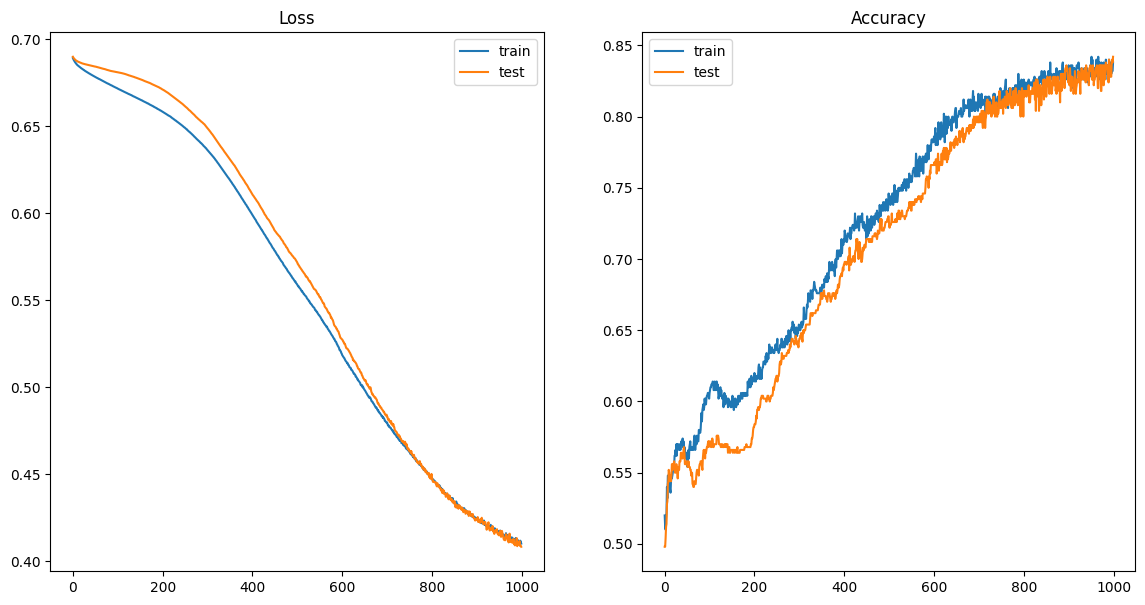

In [ ]:
# binary cross entropy:
keras.backend.clear_session()
# Prerprocesado de los datos
n_train = 500
train_X, test_X = X[:n_train, :], X[n_train:, :]
train_y, test_y = y[:n_train], y[n_train:]
model = build_model2()
history = model.fit(train_X, train_y, validation_data=(test_X, test_y), epochs=1000, verbose=1)
# Evaluación del modelo
_, train_acc = model.evaluate(train_X, train_y, verbose=0)
_, test_acc = model.evaluate(test_X, test_y, verbose=0)
print('Train: %.3f, Test: %.3f' % (train_acc, test_acc))
# Gráficas:
plt.figure(figsize=(14,7))
# Gráfica de pérdidas durante el entrenamiento
plt.subplot(121)
plt.title('Loss')
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
# Gráfica de las precisión durante el entrenamiento
plt.subplot(122)
plt.title('Accuracy')
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='test')
plt.legend()
plt.show()

# Laboratorio
1. Para el dataset make a moon de sklearn, construir un modelo de una red neuronal con keras para clasificar los datos.

2. Para el dataset load digits, construir un modelo de red neuronal empleando keras para realizar la clasificación.

## 1. Clasificación del dataset `make_moons`

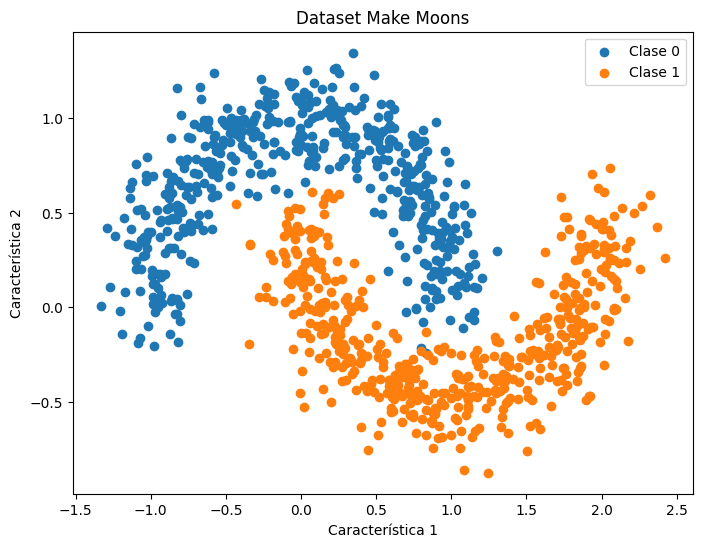

In [ ]:
from sklearn.datasets import make_moons

# Generar el dataset make_moons
X_moons, y_moons = make_moons(n_samples=1000, noise=0.15, random_state=42)

# Visualizar el dataset
plt.figure(figsize=(8, 6))
plt.scatter(X_moons[y_moons == 0, 0], X_moons[y_moons == 0, 1], label='Clase 0')
plt.scatter(X_moons[y_moons == 1, 0], X_moons[y_moons == 1, 1], label='Clase 1')
plt.title('Dataset Make Moons')
plt.xlabel('Característica 1')
plt.ylabel('Característica 2')
plt.legend()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_moons, X_test_moons, y_train_moons, y_test_moons = train_test_split(X_moons, y_moons, test_size=0.3, random_state=42)

print(f"Dimensiones de X_train_moons: {X_train_moons.shape}")
print(f"Dimensiones de y_train_moons: {y_train_moons.shape}")
print(f"Dimensiones de X_test_moons: {X_test_moons.shape}")
print(f"Dimensiones de y_test_moons: {y_test_moons.shape}")

Dimensiones de X_train_moons: (700, 2)
Dimensiones de y_train_moons: (700,)
Dimensiones de X_test_moons: (300, 2)
Dimensiones de y_test_moons: (300,)


### Construcción y entrenamiento del modelo Keras

Usaremos una arquitectura similar a la del ejemplo `make_circles`, pero adaptada para este problema. Dada la naturaleza no lineal del dataset `make_moons`, una red neuronal con capas ocultas y funciones de activación no lineales es apropiada.

In [ ]:
# Usando la función build_model2 previamente definida
# Aseguramos que la capa de entrada tenga 2 neuronas (para las 2 características de make_moons)
# Y que la capa de salida use activación sigmoide para clasificación binaria

keras.backend.clear_session()

model_moons = build_model2(activation='sigmoid', loss='binary_crossentropy')
model_moons.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61 (244.00 B)

 Trainable params: 61 (244.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenar el modelo
history_moons = model_moons.fit(X_train_moons, y_train_moons, validation_data=(X_test_moons, y_test_moons), epochs=500, verbose=0)

# Evaluar el modelo
_, train_acc_moons = model_moons.evaluate(X_train_moons, y_train_moons, verbose=0)
_, test_acc_moons = model_moons.evaluate(X_test_moons, y_test_moons, verbose=0)
print('Precisión en entrenamiento: %.3f, Precisión en prueba: %.3f' % (train_acc_moons, test_acc_moons))

Precisión en entrenamiento: 0.963, Precisión en prueba: 0.973


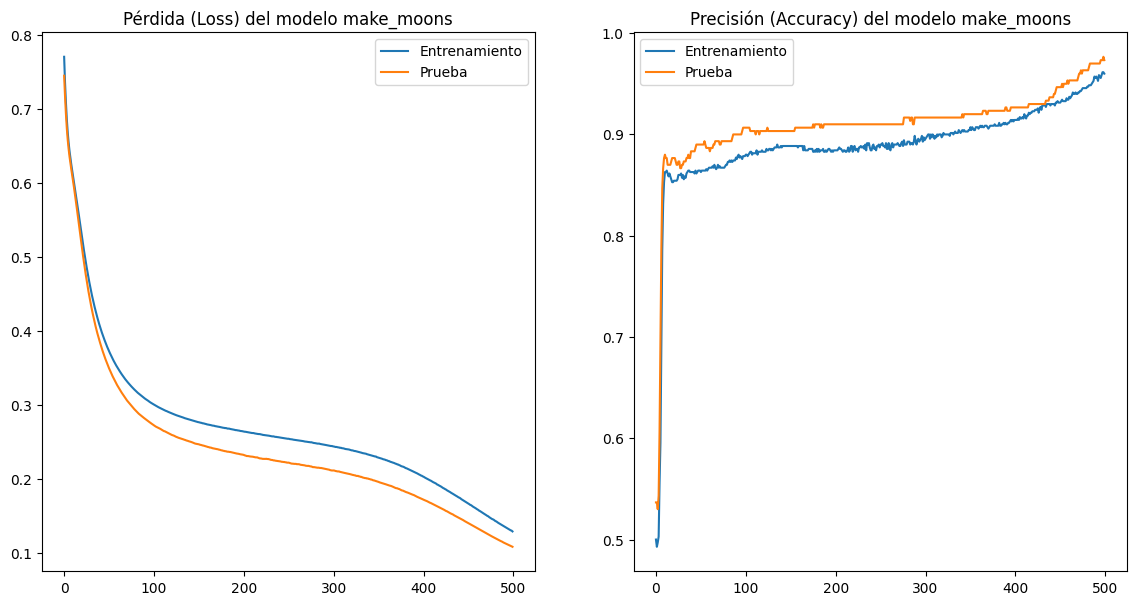

In [ ]:
# Gráficas de pérdidas y precisión durante el entrenamiento
plt.figure(figsize=(14,7))

# Gráfica de pérdidas
plt.subplot(121)
plt.title('Pérdida (Loss) del modelo make_moons')
plt.plot(history_moons.history['loss'], label='Entrenamiento')
plt.plot(history_moons.history['val_loss'], label='Prueba')
plt.legend()

# Gráfica de precisión
plt.subplot(122)
plt.title('Precisión (Accuracy) del modelo make_moons')
plt.plot(history_moons.history['accuracy'], label='Entrenamiento')
plt.plot(history_moons.history['val_accuracy'], label='Prueba')
plt.legend()
plt.show()

### Visualización de la frontera de decisión

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


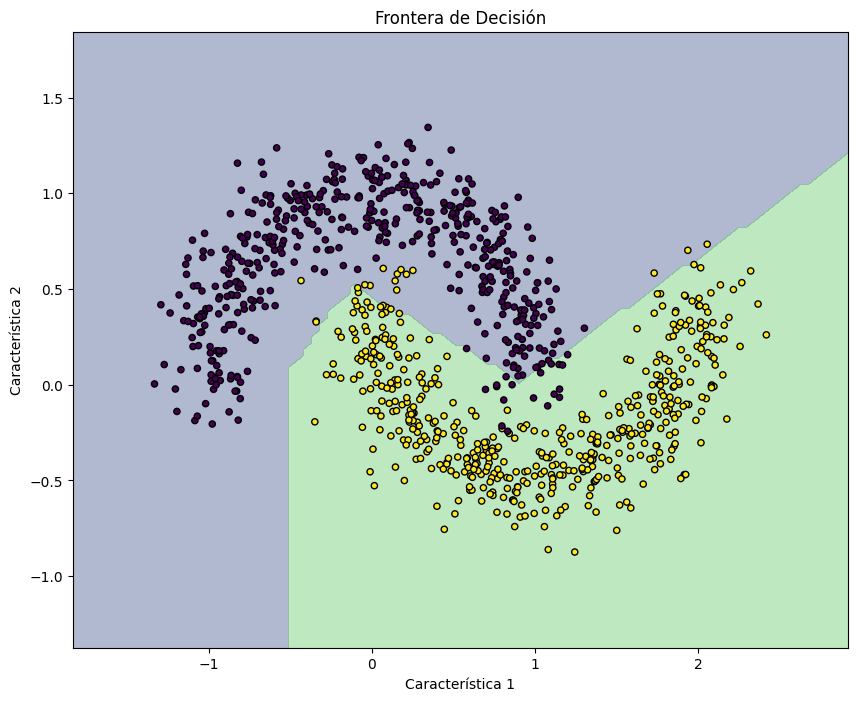

In [ ]:
def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = (Z > 0.5).reshape(xx.shape) # Para clasificación binaria con sigmoide

    plt.contourf(xx, yy, Z, alpha=0.4)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k')
    plt.title('Frontera de Decisión')
    plt.xlabel('Característica 1')
    plt.ylabel('Característica 2')
    plt.show()

plt.figure(figsize=(10, 8))
plot_decision_boundary(X_moons, y_moons, model_moons)

## 2. Clasificación del dataset `load_digits`

In [ ]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

# Cargar el dataset load_digits
digits = load_digits()
X_digits, y_digits = digits.data, digits.target
n_samples_digits, n_features_digits = X_digits.shape
n_classes_digits = len(np.unique(y_digits))

print(f"Número de muestras: {n_samples_digits}")
print(f"Número de características (píxeles): {n_features_digits}")
print(f"Número de clases (dígitos): {n_classes_digits}")

Número de muestras: 1797
Número de características (píxeles): 64
Número de clases (dígitos): 10


### Visualización de los dígitos

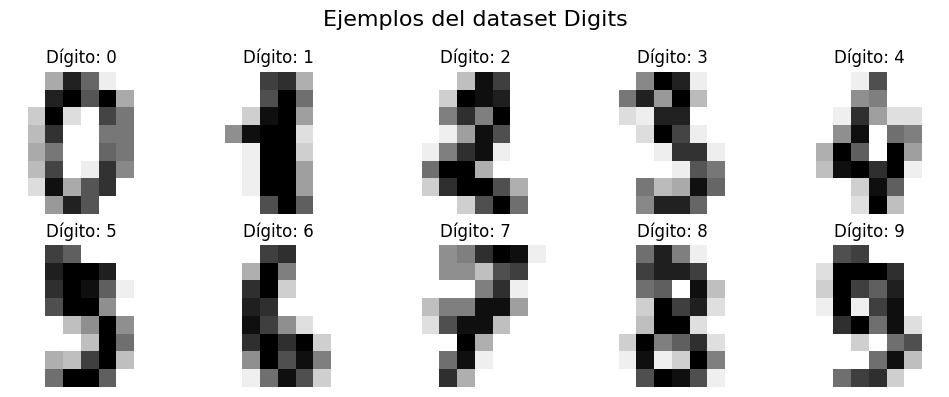

In [ ]:
fig, axs = plt.subplots(nrows=2, ncols=5, figsize=(10, 4))
for idx, ax in enumerate(axs.ravel()):
    ax.imshow(X_digits[idx].reshape((8, 8)), cmap=plt.cm.binary)
    ax.set_title(f'Dígito: {y_digits[idx]}')
    ax.axis('off')
_ = fig.suptitle('Ejemplos del dataset Digits', fontsize=16)
plt.tight_layout()
plt.show()

### Preparación de los datos para Keras

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_digits, X_test_digits, y_train_digits, y_test_digits = train_test_split(X_digits, y_digits, test_size=0.2, random_state=42)

# Normalizar los datos de entrada (imágenes con valores de píxeles entre 0 y 16)
# La normalización a [0, 1] es estándar para redes neuronales
X_train_digits = X_train_digits / 16.0
X_test_digits = X_test_digits / 16.0

# Convertir las etiquetas a formato one-hot encoding para clasificación multiclase
y_train_digits_cat = to_categorical(y_train_digits, num_classes=n_classes_digits)
y_test_digits_cat = to_categorical(y_test_digits, num_classes=n_classes_digits)

print(f"Dimensiones de X_train_digits: {X_train_digits.shape}")
print(f"Dimensiones de y_train_digits_cat: {y_train_digits_cat.shape}")
print(f"Dimensiones de X_test_digits: {X_test_digits.shape}")
print(f"Dimensiones de y_test_digits_cat: {y_test_digits_cat.shape}")

Dimensiones de X_train_digits: (1437, 64)
Dimensiones de y_train_digits_cat: (1437, 10)
Dimensiones de X_test_digits: (360, 64)
Dimensiones de y_test_digits_cat: (360, 10)


### Construcción y entrenamiento del modelo Keras para `load_digits`

In [ ]:
def build_digits_model(input_dim, output_dim):
  model = keras.models.Sequential()
  model.add(keras.layers.Dense(128, input_dim=input_dim, activation='relu'))
  model.add(keras.layers.Dense(64, activation='relu'))
  model.add(keras.layers.Dense(output_dim, activation='softmax')) # Softmax para clasificación multiclase

  opt = keras.optimizers.Adam(learning_rate=0.001) # Usamos Adam optimizer
  model.compile(loss='categorical_crossentropy', optimizer=opt, metrics=['accuracy']) # Categorical crossentropy para multiclase
  return model

keras.backend.clear_session()

model_digits = build_digits_model(n_features_digits, n_classes_digits)
model_digits.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,226 (67.29 KB)

 Trainable params: 17,226 (67.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entrenar el modelo
history_digits = model_digits.fit(X_train_digits, y_train_digits_cat,
                                  validation_data=(X_test_digits, y_test_digits_cat),
                                  epochs=50, verbose=1)

# Evaluar el modelo
_, train_acc_digits = model_digits.evaluate(X_train_digits, y_train_digits_cat, verbose=0)
_, test_acc_digits = model_digits.evaluate(X_test_digits, y_test_digits_cat, verbose=0)
print('Precisión en entrenamiento (Digits): %.3f, Precisión en prueba (Digits): %.3f' % (train_acc_digits, test_acc_digits))

Epoch 1/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5296 - loss: 1.9022 - val_accuracy: 0.8333 - val_loss: 1.3452
Epoch 2/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8636 - loss: 0.8902 - val_accuracy: 0.9167 - val_loss: 0.4963
Epoch 3/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9200 - loss: 0.3916 - val_accuracy: 0.9472 - val_loss: 0.2695
Epoch 4/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9464 - loss: 0.2531 - val_accuracy: 0.9500 - val_loss: 0.2028
Epoch 5/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9576 - loss: 0.1908 - val_accuracy: 0.9583 - val_loss: 0.1753
Epoch 6/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9659 - loss: 0.1522 - val_accuracy: 0.9667 - val_loss: 0.1481
Epoch 7/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9694 - loss: 0.1315 - val_accuracy: 0.9639 - val_loss: 0.1276
Epoch 8/50
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9687 - loss: 0.1156 - val_accuracy: 0.9750 - val_loss:

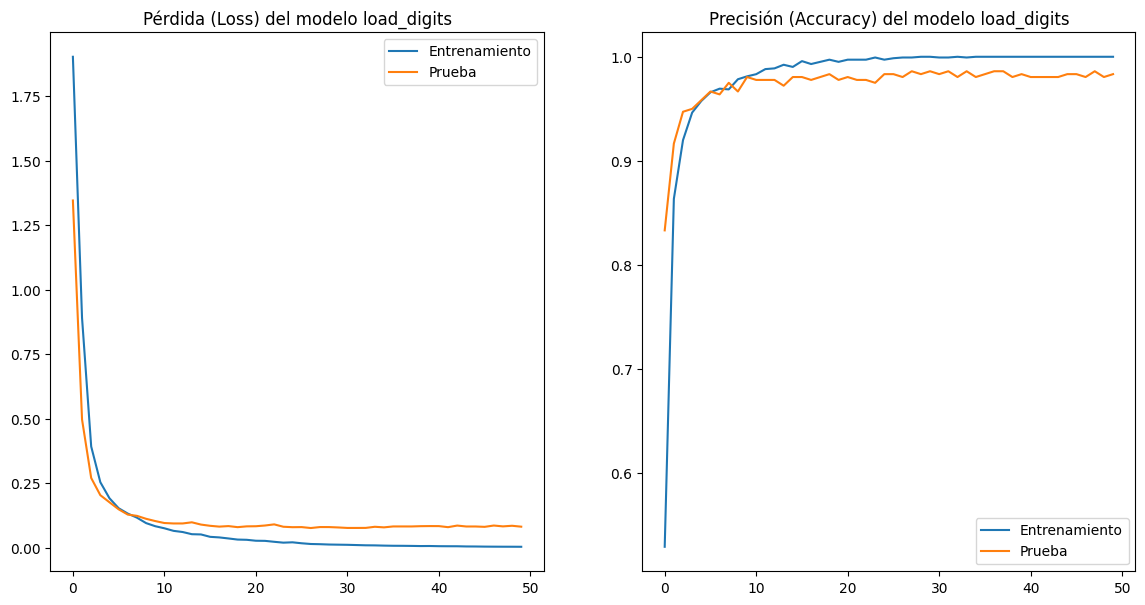

In [ ]:
# Gráficas de pérdidas y precisión durante el entrenamiento
plt.figure(figsize=(14,7))

# Gráfica de pérdidas
plt.subplot(121)
plt.title('Pérdida (Loss) del modelo load_digits')
plt.plot(history_digits.history['loss'], label='Entrenamiento')
plt.plot(history_digits.history['val_loss'], label='Prueba')
plt.legend()

# Gráfica de precisión
plt.subplot(122)
plt.title('Precisión (Accuracy) del modelo load_digits')
plt.plot(history_digits.history['accuracy'], label='Entrenamiento')
plt.plot(history_digits.history['val_accuracy'], label='Prueba')
plt.legend()
plt.show()

## 3. Demostración de Overfitting con `make_moons`

Para demostrar el overfitting, construiremos un modelo más complejo y lo entrenaremos por un número excesivo de épocas en el dataset `make_moons`. Un modelo con más capacidad de la necesaria para los datos, entrenado por mucho tiempo, comenzará a memorizar el ruido en los datos de entrenamiento en lugar de aprender el patrón general, lo que resultará en un buen rendimiento en el entrenamiento pero un rendimiento deficiente en los datos de prueba.

### Construcción del modelo para Overfitting

In [ ]:
# Definimos un modelo más complejo para forzar el overfitting
def build_overfitting_model_moons(input_dim, output_dim, activation='sigmoid', loss='binary_crossentropy'):
  model = keras.models.Sequential()
  model.add(keras.layers.Dense(256, input_dim=input_dim, activation='relu')) # Más neuronas
  model.add(keras.layers.Dense(128, activation='relu')) # Nueva capa oculta
  model.add(keras.layers.Dense(64, activation='relu')) # Nueva capa oculta
  model.add(keras.layers.Dense(output_dim, activation=activation))
  opt = keras.optimizers.Adam(learning_rate=0.001) # Usamos Adam para un entrenamiento más rápido
  model.compile(loss=loss, optimizer=opt, metrics=['accuracy'])
  return model

keras.backend.clear_session()

# Creamos el modelo de overfitting
model_moons_overfit = build_overfitting_model_moons(input_dim=X_train_moons.shape[1], output_dim=1)
model_moons_overfit.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,985 (164.00 KB)

 Trainable params: 41,985 (164.00 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento del modelo (con muchas épocas para overfitting)

In [ ]:
# Entrenar el modelo con muchas más épocas
history_moons_overfit = model_moons_overfit.fit(X_train_moons, y_train_moons,
                                                validation_data=(X_test_moons, y_test_moons),
                                                epochs=1000, verbose=0) # Aumentamos las épocas significativamente

# Evaluar el modelo
_, train_acc_moons_overfit = model_moons_overfit.evaluate(X_train_moons, y_train_moons, verbose=0)
_, test_acc_moons_overfit = model_moons_overfit.evaluate(X_test_moons, y_test_moons, verbose=0)
print('Precisión en entrenamiento (Overfit): %.3f, Precisión en prueba (Overfit): %.3f' % (train_acc_moons_overfit, test_acc_moons_overfit))

Precisión en entrenamiento (Overfit): 0.999, Precisión en prueba (Overfit): 0.990


### Visualización de resultados de Overfitting

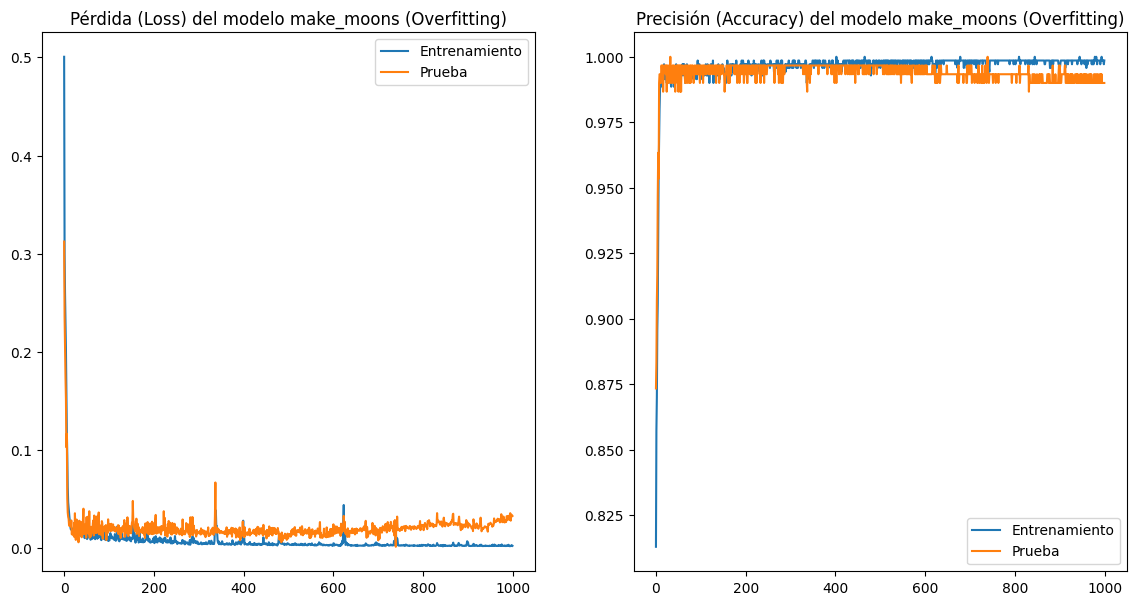

In [ ]:
# Gráficas de pérdidas y precisión durante el entrenamiento
plt.figure(figsize=(14,7))

# Gráfica de pérdidas
plt.subplot(121)
plt.title('Pérdida (Loss) del modelo make_moons (Overfitting)')
plt.plot(history_moons_overfit.history['loss'], label='Entrenamiento')
plt.plot(history_moons_overfit.history['val_loss'], label='Prueba')
plt.legend()

# Gráfica de precisión
plt.subplot(122)
plt.title('Precisión (Accuracy) del modelo make_moons (Overfitting)')
plt.plot(history_moons_overfit.history['accuracy'], label='Entrenamiento')
plt.plot(history_moons_overfit.history['val_accuracy'], label='Prueba')
plt.legend()
plt.show()

Podemos ver en la gráfica de precisión que de manera muy rápida la gráfica subió, esto está relacionado directamente con el aprendizaje. Es decir, aprendió muy rápido y con pocos datos, pero esto no es directamente proporcional con que los resultados puedan ser mejores.

### Visualización de la frontera de decisión del modelo con Overfitting

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


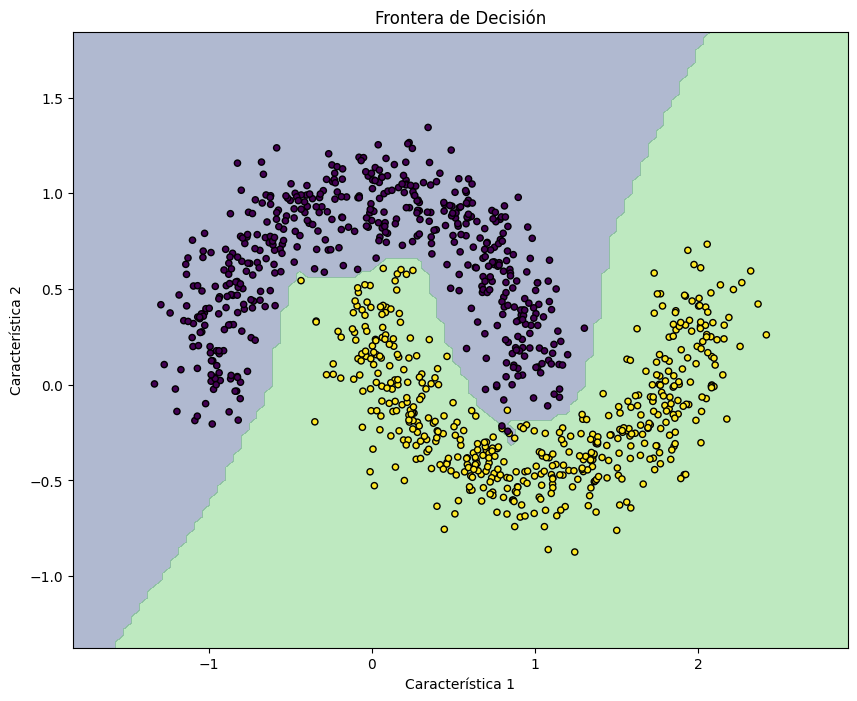

In [ ]:
plt.figure(figsize=(10, 8))
plot_decision_boundary(X_moons, y_moons, model_moons_overfit)

Como se puede observar en las gráficas de pérdida y precisión, la pérdida de entrenamiento continúa disminuyendo mientras que la pérdida de prueba empieza a aumentar o se estanca, y la precisión de entrenamiento sigue subiendo mientras que la de prueba se estabiliza o incluso disminuye. Esto es una clara señal de overfitting. La frontera de decisión también podría mostrar una forma excesivamente compleja, tratando de clasificar puntos de ruido individuales.

## 4. Demostración de Underfitting con `make_moons`

Para demostrar el underfitting, construiremos un modelo con muy poca capacidad (pocas capas o pocas neuronas) y/o lo entrenaremos por un número insuficiente de épocas. Un modelo que sufre de underfitting no logrará capturar los patrones subyacentes en los datos de entrenamiento, resultando en un rendimiento pobre tanto en los datos de entrenamiento como en los de prueba.

### Construcción del modelo para Underfitting

In [ ]:
# Definimos un modelo muy simple para forzar el underfitting
def build_underfitting_model_moons(input_dim, output_dim, activation='sigmoid', loss='binary_crossentropy'):
  model = keras.models.Sequential()
  model.add(keras.layers.Dense(4, input_dim=input_dim, activation='relu')) # Muy pocas neuronas en una sola capa oculta
  model.add(keras.layers.Dense(output_dim, activation=activation))
  opt = keras.optimizers.SGD(learning_rate=0.01) # Usamos SGD para un entrenamiento más lento y menor capacidad
  model.compile(loss=loss, optimizer=opt, metrics=['accuracy'])
  return model

keras.backend.clear_session()

# Creamos el modelo de underfitting
model_moons_underfit = build_underfitting_model_moons(input_dim=X_train_moons.shape[1], output_dim=1)
model_moons_underfit.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento del modelo (con pocas épocas y modelo simple)

In [ ]:
# Entrenar el modelo con pocas épocas para acentuar el underfitting
history_moons_underfit = model_moons_underfit.fit(X_train_moons, y_train_moons,
                                                  validation_data=(X_test_moons, y_test_moons),
                                                  epochs=50, verbose=0) # Pocas épocas

# Evaluar el modelo
_, train_acc_moons_underfit = model_moons_underfit.evaluate(X_train_moons, y_train_moons, verbose=0)
_, test_acc_moons_underfit = model_moons_underfit.evaluate(X_test_moons, y_test_moons, verbose=0)
print('Precisión en entrenamiento (Underfit): %.3f, Precisión en prueba (Underfit): %.3f' % (train_acc_moons_underfit, test_acc_moons_underfit))

Precisión en entrenamiento (Underfit): 0.827, Precisión en prueba (Underfit): 0.850


### Visualización de resultados de Underfitting

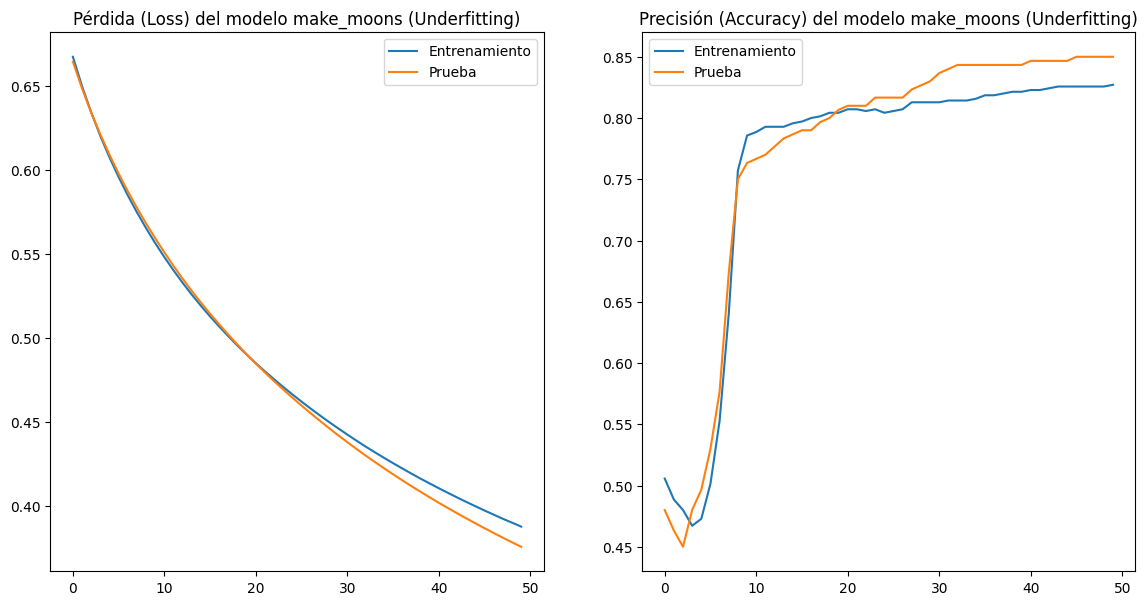

In [ ]:
# Gráficas de pérdidas y precisión durante el entrenamiento
plt.figure(figsize=(14,7))

# Gráfica de pérdidas
plt.subplot(121)
plt.title('Pérdida (Loss) del modelo make_moons (Underfitting)')
plt.plot(history_moons_underfit.history['loss'], label='Entrenamiento')
plt.plot(history_moons_underfit.history['val_loss'], label='Prueba')
plt.legend()

# Gráfica de precisión
plt.subplot(122)
plt.title('Precisión (Accuracy) del modelo make_moons (Underfitting)')
plt.plot(history_moons_underfit.history['accuracy'], label='Entrenamiento')
plt.plot(history_moons_underfit.history['val_accuracy'], label='Prueba')
plt.legend()
plt.show()

### Visualización de la frontera de decisión del modelo con Underfitting

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


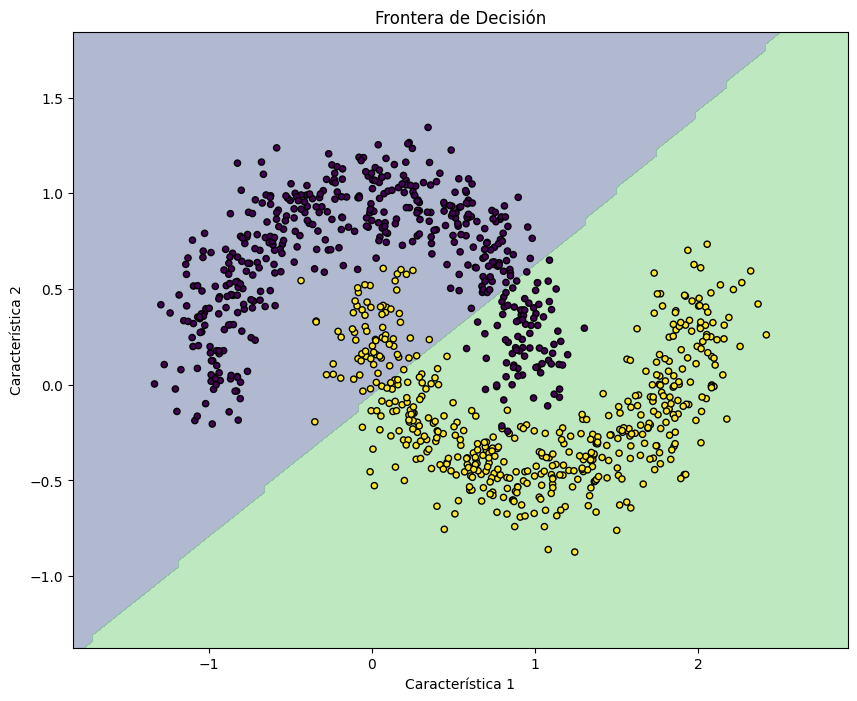

In [ ]:
plt.figure(figsize=(10, 8))
plot_decision_boundary(X_moons, y_moons, model_moons_underfit)

Como se puede observar en las gráficas de pérdida y precisión, ambos valores (entrenamiento y prueba) se mantienen relativamente altos (para la pérdida) y bajos (para la precisión), y no logran mejorar significativamente. Esto indica que el modelo no ha aprendido los patrones esenciales en los datos, lo que es una clara señal de underfitting. La frontera de decisión será muy simple y no logrará separar adecuadamente las dos clases.